In [34]:
# -------------------------------------------------------------
# STEP 01 - Carga e auditoria das transacoes cruas
# Carga da base, auditoria de nulos e descarte de registros invalidos.
# -------------------------------------------------------------
import pandas as pd
import numpy as np
import os

INPUT_FILE = 'Base_Estudo_PIB_IDH.csv'
os.makedirs('output', exist_ok=True)

df = pd.read_csv(INPUT_FILE, sep=';', decimal=',')

# total antes de limpar
total_original = len(df)

# normaliza strings de nulo para NaN para o dropna agir de fato
df.replace(to_replace=["null", "NULL", ""], value=np.nan, inplace=True)
dados = df.dropna()

# aproveitamento real
total_aproveitados = len(dados)
aproveitamento = (total_aproveitados / total_original) * 100

resultados_df = pd.DataFrame({
    "Originais": [total_original],
    "Aproveitados": [total_aproveitados],
    "Aproveitamento (%)": [f"{aproveitamento:.1f}"]
})

print(resultados_df)

dados.to_csv('output/base_step_01.csv', sep=';', index=False, encoding='utf-8-sig')

   Originais  Aproveitados Aproveitamento (%)
0        465           465              100.0


In [35]:
# -------------------------------------------------------------
# STEP 02 - Tabela descritiva das variaveis qualitativas
# Le a saida do STEP 01 e gera a tabela: Variavel, Categorias, Moda.
# Qualitativa = coluna que nao converte para numero em nenhum valor.
# -------------------------------------------------------------
import pandas as pd

dados = pd.read_csv('output/base_step_01.csv', sep=';', decimal=',', encoding='utf-8-sig')

def eh_qualitativa(serie):
    numerico = pd.to_numeric(serie.dropna().astype(str).str.replace(',', '.'), errors='coerce')
    return numerico.notna().sum() == 0

qualitativas = [c for c in dados.columns if eh_qualitativa(dados[c])]

linhas = []
for col in qualitativas:
    categorias = ', '.join(sorted(dados[col].dropna().unique().astype(str)))
    moda = dados[col].mode().iloc[0]
    linhas.append({'Variavel': col, 'Categorias': categorias, 'Moda': moda})

tabela = pd.DataFrame(linhas, columns=['Variavel', 'Categorias', 'Moda'])

print(tabela.to_string(index=False))

           Variavel                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                Categorias                              Moda
             regiao                                                                                                                                                                                                                                                                                                                                     

In [36]:
# -------------------------------------------------------------
# STEP 03 - Tabela descritiva das variaveis quantitativas
# Le a saida do STEP 01 e gera a tabela com:
# Variavel, Min., Max., Media, 1o quartil, Mediana, 3o quartil.
# Quantitativa = coluna que converte integralmente para numero.
# -------------------------------------------------------------
import pandas as pd

dados = pd.read_csv('output/base_step_01.csv', sep=';', decimal=',', encoding='utf-8-sig')

def como_numero(serie):
    return pd.to_numeric(serie.dropna().astype(str).str.replace(',', '.'), errors='coerce')

quantitativas = [c for c in dados.columns
                 if not dados[c].dropna().empty
                 and como_numero(dados[c]).notna().sum() == len(dados[c].dropna())]

linhas = []
for col in quantitativas:
    s = como_numero(dados[col])
    linhas.append({
        'Variavel': col,
        'Min.': s.min(),
        'Max.': s.max(),
        'Media': s.mean(),
        '1o quartil': s.quantile(0.25),
        'Mediana': s.median(),
        '3o quartil': s.quantile(0.75)
    })

tabela = pd.DataFrame(linhas, columns=['Variavel', 'Min.', 'Max.', 'Media',
                                       '1o quartil', 'Mediana', '3o quartil'])

# formatacao legivel: separador de milhar e 2 casas decimais
pd.options.display.float_format = lambda x: f'{x:,.2f}'

print(tabela.to_string(index=False))

                                Variavel          Min.             Max.          Media     1o quartil        Mediana     3o quartil
                         exerciciofiscal      2,018.00         2,022.00       2,020.11       2,019.00       2,020.00       2,021.00
                              Autorizado          0.00 2,414,054,843.00  63,757,802.93     350,000.00   1,555,000.00  17,742,156.00
                                    Pago          0.00 1,181,199,939.00  24,929,729.08           0.00      23,750.00     983,903.32
                          Autorizado_USD          0.00   467,840,085.90  13,687,845.67      74,074.07     355,329.95   3,856,394.07
                                Pago_USD          0.00   218,740,729.40   5,345,219.69           0.00       5,071.39     206,511.22
                                     IDH          0.68             0.86           0.76           0.73           0.76           0.77
                               Populacao    513,466.00   214,448,798.00  55,

In [37]:
# -------------------------------------------------------------
# STEP 04 - Encoding categorico completo
# Le a base limpa do STEP 01, aplica one-hot em tipoacao, regiao e
# unidadeorcamentaria, e salva a base preparada com todas as dummies.
# Nao filtra features aqui. Cada o modelo seleciona as suas
# nos steps seguintes, pois usam conjuntos diferentes.
# -------------------------------------------------------------
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

dados = pd.read_csv('output/base_step_01.csv', sep=';', decimal=',', encoding='utf-8-sig')

# one-hot encoding dos atributos categoricos
categoricas = ['tipoacao', 'regiao', 'unidadeorcamentaria']  # Selecao realizada por decisao de negocio
encoder = OneHotEncoder(sparse_output=False)
encoded_data = encoder.fit_transform(dados[categoricas])
encoded_columns = encoder.get_feature_names_out(categoricas)
df_encoded = pd.DataFrame(encoded_data, columns=encoded_columns, index=dados.index)

df = pd.concat([dados, df_encoded], axis=1)
df = df.drop(columns=categoricas)

df.to_csv('output/base_step_04.csv', sep=';', index=False, encoding='utf-8-sig')

print(f"Base preparada: {df.shape[0]} linhas, {df.shape[1]} colunas")
print(f"Dummies geradas ({len(encoded_columns)}):")
for c in encoded_columns:
    print(f"  {c}")
print("Salvo em output/base_step_04.csv")

Base preparada: 465 linhas, 46 colunas
Dummies geradas (14):
  tipoacao_CAPEX
  tipoacao_OPEX
  tipoacao_Operação Especial
  regiao_BR
  regiao_Centro-Oeste
  regiao_Nordeste
  regiao_Norte
  regiao_Sudeste
  regiao_Sul
  unidadeorcamentaria_CONAB
  unidadeorcamentaria_EMBRAPA
  unidadeorcamentaria_INCRA
  unidadeorcamentaria_MAPA
  unidadeorcamentaria_SFB
Salvo em output/base_step_04.csv


Matriz de correlacao IDH (14 features)
Nenhum par com |correlacao| > 0.7.


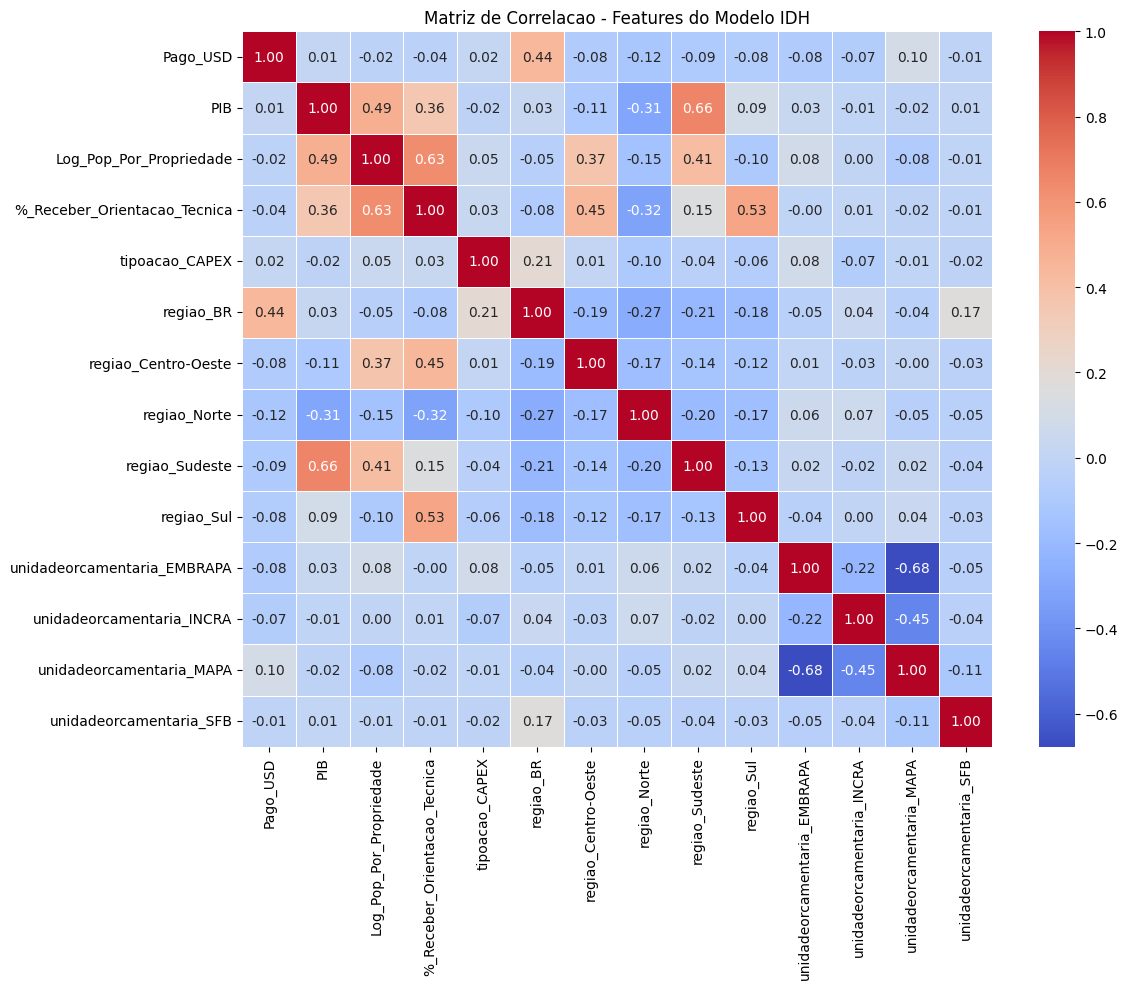

Salvo em output/base_step_05_corr_idh.csv e output/base_step_05_corr_idh.png


In [38]:
# -------------------------------------------------------------
# STEP 05 IDH - Matriz de correlacao das features do modelo IDH
# Le a base com dummies do STEP 04, calcula a correlacao das 14
# features do modelo IDH, salva a matriz e sinaliza os pares com
# correlacao absoluta acima de 0,7 (criterio de multicolinearidade
# do TCC). Nao remove nada, apenas diagnostica.
# -------------------------------------------------------------
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('output/base_step_04.csv', sep=';', decimal=',', encoding='utf-8-sig')

# 14 features do modelo IDH
features_idh = [
    'Pago_USD',
    'PIB',
    'Log_Pop_Por_Propriedade',
    '%_Receber_Orientacao_Tecnica',
    'tipoacao_CAPEX',
    'regiao_BR',
    'regiao_Centro-Oeste',
    'regiao_Norte',
    'regiao_Sudeste',
    'regiao_Sul',
    'unidadeorcamentaria_EMBRAPA',
    'unidadeorcamentaria_INCRA',
    'unidadeorcamentaria_MAPA',
    'unidadeorcamentaria_SFB'
]

corr = df[features_idh].corr()

# salvar a matriz
corr.to_csv('output/base_step_05_corr_idh.csv', sep=';', encoding='utf-8-sig')

# sinalizar pares com correlacao absoluta acima de 0,7 (multicolinearidade)
LIMIAR = 0.7
pares_altos = []
for i in range(len(features_idh)):
    for j in range(i + 1, len(features_idh)):
        valor = corr.iloc[i, j]
        if abs(valor) > LIMIAR:
            pares_altos.append((features_idh[i], features_idh[j], round(valor, 3)))

print(f"Matriz de correlacao IDH ({len(features_idh)} features)")
if pares_altos:
    print(f"Pares com |correlacao| > {LIMIAR} (potencial multicolinearidade):")
    for a, b, v in pares_altos:
        print(f"  {a} x {b}: {v}")
else:
    print(f"Nenhum par com |correlacao| > {LIMIAR}.")

# plotar
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlacao - Features do Modelo IDH')
plt.tight_layout()
plt.savefig('output/base_step_05_corr_idh.png', dpi=150)
plt.show()
plt.close()

print("Salvo em output/base_step_05_corr_idh.csv e output/base_step_05_corr_idh.png")

In [39]:
# -------------------------------------------------------------
# STEP 06 IDH - Modelo (XGBoost)
# Le a base com dummies do STEP 04, treina XGBoost para prever IDH.
# As features sao definidas teoricamente (lista fixa). O RFE permanece
# no pipeline por consistencia de mecanica, mas nao reduz o conjunto.
# Otimizacao de hiperparametros via GridSearchCV.
# -------------------------------------------------------------
import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor

# Fonte correta: a base com dummies do STEP 04, nao a matriz de correlacao
df = pd.read_csv('output/base_step_04.csv', sep=';', decimal=',', encoding='utf-8-sig')

# -------------------------------------------------------------
# Selecao teorica das 14 features (hypothesis-driven), nao automatica.
# Cada variavel tem um fundamento de negocio para estar no modelo (deliberado por consenso).
#   - capacidade de investimento: Pago_USD, tipoacao_CAPEX
#   - riqueza regional: PIB
#   - pressao demografica sobre a terra: Log_Pop_Por_Propriedade
#   - acesso a assistencia tecnica: %_Receber_Orientacao_Tecnica
#   - controles estruturais: blocos de regiao e unidade orcamentaria
# Conjunto fixo garante interpretabilidade e comparabilidade entre os
# modelos do pipeline (coeficientes e importancias estaveis e lado a lado).
# Evita a correlacao espuria que a selecao automatica costuma gerar,
# tratando ruido como se fosse poder explicativo.
# -------------------------------------------------------------

ALVO = 'IDH'
N_FEATURES = 14
features = [
    'Pago_USD',
    'PIB',
    'Log_Pop_Por_Propriedade',
    '%_Receber_Orientacao_Tecnica',
    'tipoacao_CAPEX',
    'regiao_BR',
    'regiao_Centro-Oeste',
    'regiao_Norte',
    'regiao_Sudeste',
    'regiao_Sul',
    'unidadeorcamentaria_EMBRAPA',
    'unidadeorcamentaria_INCRA',
    'unidadeorcamentaria_MAPA',
    'unidadeorcamentaria_SFB'
]

# Garante tipo numerico nas colunas usadas (o CSV vem com virgula decimal,
# entao colunas com texto residual poderiam ficar como object)
colunas = features + [ALVO]
for c in colunas:
    df[c] = pd.to_numeric(df[c].astype(str).str.replace(',', '.'), errors='coerce')
df = df.dropna(subset=colunas)

X = df[features]
y = df[ALVO]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# pipeline: normalizacao -> selecao RFE -> XGBoost
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('rfe', RFE(LinearRegression(), n_features_to_select=N_FEATURES, step=1)),
    ('xgb', XGBRegressor(random_state=42))
])

param_grid = {
    'xgb__n_estimators': [100, 200, 300],
    'xgb__max_depth': [3, 5, 7],
    'xgb__learning_rate': [0.01, 0.1, 0.2],
    'xgb__reg_alpha': [0, 0.1, 0.5],
    'xgb__reg_lambda': [0, 0.1, 0.5]
}

grid_search = GridSearchCV(pipe, param_grid, scoring='neg_mean_squared_error', cv=5)
grid_search.fit(X_train, y_train)
best = grid_search.best_estimator_

# --- avaliacao (resultado principal) ---
y_pred = best.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=" * 55)
print(f"MODELO {ALVO} - DESEMPENHO")
print("=" * 55)
print(f"R2 Score : {r2:.18f}")
print(f"RMSE     : {rmse:.18f}")
print(f"MAE      : {mae:.18f}")
print(f"MSE      : {mse:.18e}")
hp = {k.replace('xgb__', ''): v for k, v in grid_search.best_params_.items()}
print(f"Hiperparametros: {hp}")

# --- importancia das features (resultado secundario) ---
sel = X_train.columns[best.named_steps['rfe'].support_]
importancia = pd.DataFrame({
    'Feature': sel,
    'Importancia': best.named_steps['xgb'].feature_importances_
}).sort_values('Importancia', ascending=False).reset_index(drop=True)

print("\nIMPORTANCIA DAS FEATURES")
for _, r in importancia.iterrows():
    print(f"  {r['Feature']:<35}{r['Importancia']:.6f}")

# --- persistencia ---
importancia.to_csv('output/base_step_06_importancia_idh.csv', sep=';', index=False, encoding='utf-8-sig')
with open('output/modelo_idh_step_06.pkl', 'wb') as f:
    pickle.dump(best, f)

print("\nSalvo: output/modelo_idh_step_06.pkl, output/base_step_06_importancia_idh.csv")

MODELO IDH - DESEMPENHO
R2 Score : 0.963193288707062223
RMSE     : 0.007122063226895046
MAE      : 0.003743644524646064
MSE      : 5.072378460789067059e-05
Hiperparametros: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100, 'reg_alpha': 0, 'reg_lambda': 0}

IMPORTANCIA DAS FEATURES
  %_Receber_Orientacao_Tecnica       0.521084
  regiao_Sudeste                     0.318894
  regiao_Centro-Oeste                0.106709
  Log_Pop_Por_Propriedade            0.017870
  PIB                                0.011041
  regiao_BR                          0.010882
  tipoacao_CAPEX                     0.004801
  regiao_Norte                       0.003557
  Pago_USD                           0.003508
  unidadeorcamentaria_EMBRAPA        0.000697
  unidadeorcamentaria_INCRA          0.000426
  regiao_Sul                         0.000366
  unidadeorcamentaria_MAPA           0.000165
  unidadeorcamentaria_SFB            0.000000

Salvo: output/modelo_idh_step_06.pkl, output/base_step_06_impor

In [40]:
# -------------------------------------------------------------
# STEP 07 IDH - Modelo (XGBoost) com selecao automatica de features
# Le a base com dummies do STEP 04 e preve IDH.
#
# Selecao em duas camadas, ambas sem vazamento:
#   1. Poda de multicolinearidade (|corr| > 0.7) calculada SO no treino.
#      Entre dois features colineares, remove o mais redundante
#      (maior correlacao media com os demais).
#   2. RFE dentro do Pipeline, com o numero de features varrido pelo
#      GridSearchCV. A validacao cruzada escolhe quantas features e
#      quais hiperparametros, reescalando dentro de cada fold.
#
# Resultado principal: R2 e metricas de erro.
# Resultado secundario: features sobreviventes e importancia.
# -------------------------------------------------------------
import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor

df = pd.read_csv('output/base_step_04.csv', sep=';', decimal=',', encoding='utf-8-sig')

ALVO = 'IDH'
# colunas que nunca entram como feature (identificadores e nao numericas)
EXCLUIR = [ALVO, 'exerciciofiscal', 'uf', 'subfuncao']
LIMIAR_CORR = 0.7

# candidatas = tudo menos alvo e excluidas, convertidas pra numero
candidatas = [c for c in df.columns if c not in EXCLUIR]
for c in candidatas + [ALVO]:
    df[c] = pd.to_numeric(df[c].astype(str).str.replace(',', '.'), errors='coerce')

# descarta candidatas que nao viraram numero de fato (viraram tudo NaN)
candidatas = [c for c in candidatas if df[c].notna().any()]
df = df.dropna(subset=candidatas + [ALVO])

X = df[candidatas]
y = df[ALVO]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# --- Camada 1: poda de multicolinearidade, so no treino ---
def podar_colineares(X_tr, limiar):
    corr = X_tr.corr().abs()
    descartadas = []
    cols = list(X_tr.columns)
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            a, b = cols[i], cols[j]
            if a in descartadas or b in descartadas:
                continue
            if corr.loc[a, b] > limiar:
                # remove o mais redundante: maior correlacao media com os demais
                red_a = corr[a].drop(a).mean()
                red_b = corr[b].drop(b).mean()
                descartadas.append(a if red_a >= red_b else b)
    mantidas = [c for c in cols if c not in descartadas]
    return mantidas, descartadas


mantidas, descartadas = podar_colineares(X_train, LIMIAR_CORR)
X_train = X_train[mantidas]
X_test = X_test[mantidas]

print("=" * 55)
print(f"SELECAO DE FEATURES - ALVO {ALVO}")
print("=" * 55)
print(f"Candidatas iniciais : {len(candidatas)}")
print(f"Podadas por |corr|>{LIMIAR_CORR} : {len(descartadas)}")
for d in descartadas:
    print(f"  - {d}")
print(f"Apos poda           : {len(mantidas)}")


# --- Camada 2: RFE seleciona quais 14 features manter ---
# Alvo de 14 features. Se a poda deixou menos que isso, o RFE usa o que tem.
N_FEATURES = 14
n_disp = len(mantidas)
n_rfe = min(N_FEATURES, n_disp)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('rfe', RFE(LinearRegression(), n_features_to_select=n_rfe, step=1)),
    ('xgb', XGBRegressor(random_state=42))
])

param_grid = {
    'xgb__n_estimators': [100, 200, 300],
    'xgb__max_depth': [3, 5, 7],
    'xgb__learning_rate': [0.01, 0.1, 0.2],
    'xgb__reg_alpha': [0, 0.1, 0.5],
    'xgb__reg_lambda': [0, 0.1, 0.5]
}

grid_search = GridSearchCV(pipe, param_grid, scoring='neg_mean_squared_error', cv=5)
grid_search.fit(X_train, y_train)
best = grid_search.best_estimator_

# --- avaliacao (resultado principal) ---
y_pred = best.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n" + "=" * 55)
print(f"MODELO {ALVO} - DESEMPENHO")
print("=" * 55)
print(f"R2 Score : {r2:.18f}")
print(f"RMSE     : {rmse:.18f}")
print(f"MAE      : {mae:.18f}")
print(f"MSE      : {mse:.18e}")
hp = {k.replace('xgb__', ''): v for k, v in grid_search.best_params_.items()}
print(f"Features RFE: {n_rfe} (de {n_disp} apos poda)")
print(f"Hiperparametros: {hp}")

# --- importancia das features selecionadas (resultado secundario) ---
sel = X_train.columns[best.named_steps['rfe'].support_]
importancia = pd.DataFrame({
    'Feature': sel,
    'Importancia': best.named_steps['xgb'].feature_importances_
}).sort_values('Importancia', ascending=False).reset_index(drop=True)

print(f"\nIMPORTANCIA DAS FEATURES (RFE manteve {len(sel)} de {len(mantidas)})")
for _, r in importancia.iterrows():
    print(f"  {r['Feature']:<35}{r['Importancia']:.6f}")

# --- persistencia ---
importancia.to_csv('output/importancia_idh.csv', sep=';', index=False, encoding='utf-8-sig')
with open('output/modelo_idh_step_07.pkl', 'wb') as f:
    pickle.dump(best, f)

print("\nSalvo: output/modelo_idh_step_07.pkl, output/importancia_idh.csv")

SELECAO DE FEATURES - ALVO IDH
Candidatas iniciais : 42
Podadas por |corr|>0.7 : 24
  - Autorizado_USD
  - Pago_USD
  - Pago
  - Populacao
  - Valor_PIB_Agronegocio
  - Valor_PIB_Agricola
  - Valor_PIB_Pecuario
  - %_PIB_Agronegocio
  - %_PIB_Pecuario
  - Total_Propriedade_Agricola
  - Populacao_Por_Propriedade
  - Norm_Pop_Por_Propriedade
  - Nao_Recebe_Orientacao_Tecnica
  - %_Nao_Recebe_Orientacao_Tecnica
  - Governo_Orientacao_Tecnica
  - Propria_Orientacao_Tecnica
  - Recebe_Orientacao_Tecnica
  - Cooperativas_Orientacao_Tecnica
  - Empresas_Privadas_Orientacao_Tecnica
  - Empresas_Integradoras_Orientacao_Tecnica
  - Sistema_S_Orientacao_Tecnica
  - Outra_Origem__Orientacao_Tecnica
  - regiao_BR
  - tipoacao_OPEX
Apos poda           : 18

MODELO IDH - DESEMPENHO
R2 Score : 0.995857350067342662
RMSE     : 0.002389359154743709
MAE      : 0.001331484804871273
MSE      : 5.709037170357573944e-06
Features RFE: 14 (de 18 apos poda)
Hiperparametros: {'learning_rate': 0.2, 'max_depth': 3,

Matriz de correlacao PIB_Agro (16 features)
Pares com |correlacao| > 0.7 (potencial multicolinearidade):
  IDH x %_Receber_Orientacao_Tecnica: 0.814


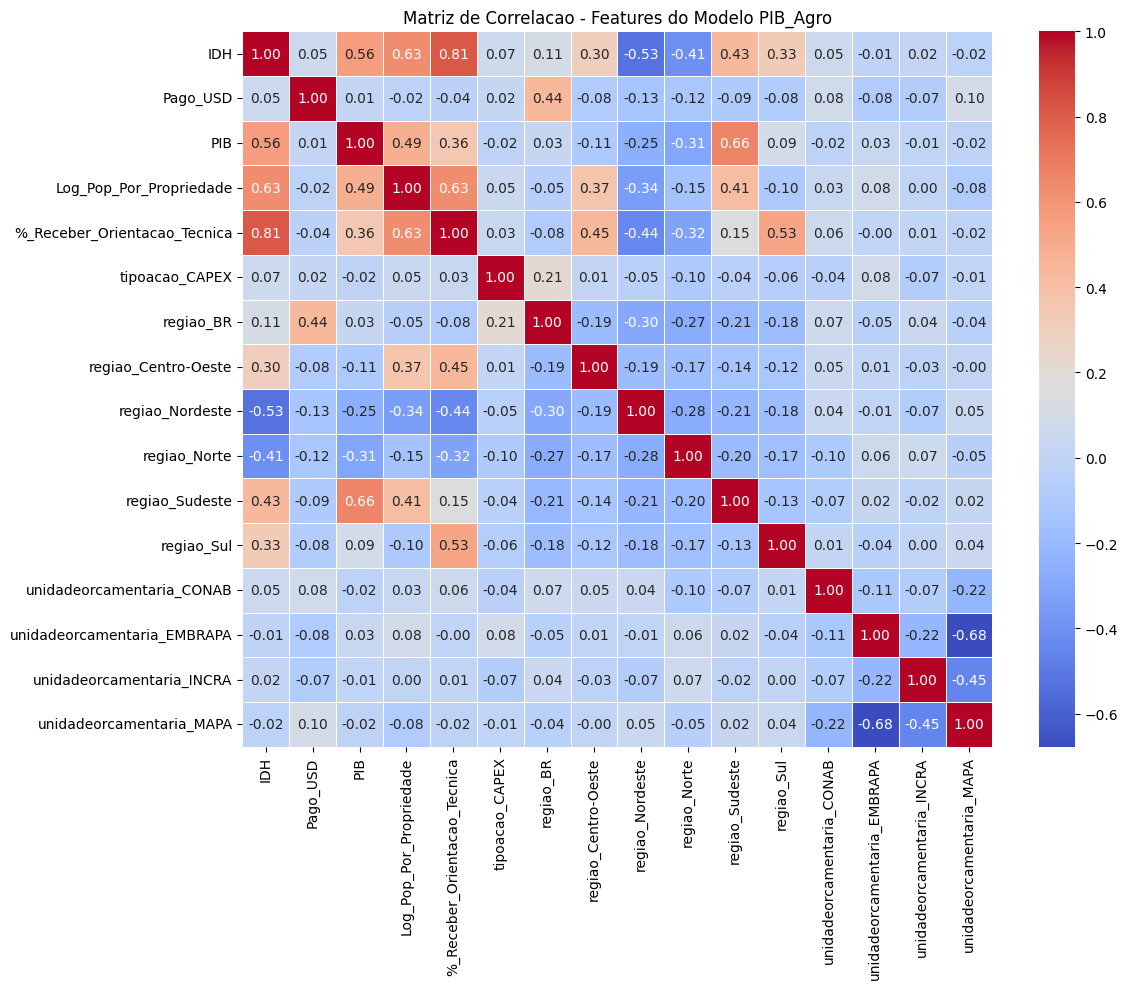

Salvo em output/base_step_08_corr_pibagro.csv e output/base_step_08_corr_pibagro.png


In [41]:
# -------------------------------------------------------------
# STEP 08 PIB_AGRO - Matriz de correlacao das features do modelo PIB_Agro
# Le a base com dummies do STEP 04, calcula a correlacao das 16
# features do modelo PIB_Agro, salva a matriz e sinaliza os pares com
# correlacao absoluta acima de 0,7 (criterio de multicolinearidade
# do TCC). Nao remove nada, apenas diagnostica.
# -------------------------------------------------------------
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('output/base_step_04.csv', sep=';', decimal=',', encoding='utf-8-sig')

# 16 features do modelo PIB_Agro
features_pibagro = [
    'IDH',
    'Pago_USD',
    'PIB',
    'Log_Pop_Por_Propriedade',
    '%_Receber_Orientacao_Tecnica',
    'tipoacao_CAPEX',
    'regiao_BR',
    'regiao_Centro-Oeste',
    'regiao_Nordeste',
    'regiao_Norte',
    'regiao_Sudeste',
    'regiao_Sul',
    'unidadeorcamentaria_CONAB',
    'unidadeorcamentaria_EMBRAPA',
    'unidadeorcamentaria_INCRA',
    'unidadeorcamentaria_MAPA'
]

corr = df[features_pibagro].corr()

# salvar a matriz
corr.to_csv('output/base_step_08_corr_pibagro.csv', sep=';', encoding='utf-8-sig')

# sinalizar pares com correlacao absoluta acima de 0,7 (multicolinearidade)
LIMIAR = 0.7
pares_altos = []
for i in range(len(features_pibagro)):
    for j in range(i + 1, len(features_pibagro)):
        valor = corr.iloc[i, j]
        if abs(valor) > LIMIAR:
            pares_altos.append((features_pibagro[i], features_pibagro[j], round(valor, 3)))

print(f"Matriz de correlacao PIB_Agro ({len(features_pibagro)} features)")
if pares_altos:
    print(f"Pares com |correlacao| > {LIMIAR} (potencial multicolinearidade):")
    for a, b, v in pares_altos:
        print(f"  {a} x {b}: {v}")
else:
    print(f"Nenhum par com |correlacao| > {LIMIAR}.")

# plotar
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlacao - Features do Modelo PIB_Agro')
plt.tight_layout()
plt.savefig('output/base_step_08_corr_pibagro.png', dpi=150)
plt.show()
plt.close()

print("Salvo em output/base_step_08_corr_pibagro.csv e output/base_step_08_corr_pibagro.png")

In [42]:
# -------------------------------------------------------------
# STEP 09 PIB_AGRO - Modelo (XGBoost)
# Le a base com dummies do STEP 04, treina XGBoost para prever
# %_PIB_Agronegocio. Features definidas teoricamente (lista fixa,
# mesmo conjunto do modelo original). O RFE permanece no pipeline
# por consistencia de mecanica. Otimizacao via GridSearchCV.
# -------------------------------------------------------------
import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor

df = pd.read_csv('output/base_step_04.csv', sep=';', decimal=',', encoding='utf-8-sig')

ALVO = '%_PIB_Agronegocio'
N_FEATURES = 16
features = [
    'Pago_USD',
    'IDH',
    'PIB',
    'Log_Pop_Por_Propriedade',
    '%_Receber_Orientacao_Tecnica',
    'tipoacao_CAPEX',
    'regiao_BR',
    'regiao_Centro-Oeste',
    'regiao_Nordeste',
    'regiao_Norte',
    'regiao_Sudeste',
    'regiao_Sul',
    'unidadeorcamentaria_CONAB',
    'unidadeorcamentaria_EMBRAPA',
    'unidadeorcamentaria_INCRA',
    'unidadeorcamentaria_MAPA'
]

colunas = features + [ALVO]
for c in colunas:
    df[c] = pd.to_numeric(df[c].astype(str).str.replace(',', '.'), errors='coerce')
df = df.dropna(subset=colunas)

X = df[features]
y = df[ALVO]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('rfe', RFE(LinearRegression(), n_features_to_select=N_FEATURES, step=1)),
    ('xgb', XGBRegressor(random_state=42))
])

param_grid = {
    'xgb__n_estimators': [100, 200, 300],
    'xgb__max_depth': [3, 5, 7],
    'xgb__learning_rate': [0.01, 0.1, 0.2],
    'xgb__reg_alpha': [0, 0.1, 0.5],
    'xgb__reg_lambda': [0, 0.1, 0.5]
}

grid_search = GridSearchCV(pipe, param_grid, scoring='neg_mean_squared_error', cv=5)
grid_search.fit(X_train, y_train)
best = grid_search.best_estimator_

y_pred = best.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=" * 55)
print(f"MODELO {ALVO} - DESEMPENHO")
print("=" * 55)
print(f"R2 Score : {r2:.18f}")
print(f"RMSE     : {rmse:.18f}")
print(f"MAE      : {mae:.18f}")
print(f"MSE      : {mse:.18e}")
hp = {k.replace('xgb__', ''): v for k, v in grid_search.best_params_.items()}
print(f"Hiperparametros: {hp}")

sel = X_train.columns[best.named_steps['rfe'].support_]
importancia = pd.DataFrame({
    'Feature': sel,
    'Importancia': best.named_steps['xgb'].feature_importances_
}).sort_values('Importancia', ascending=False).reset_index(drop=True)

print("\nIMPORTANCIA DAS FEATURES")
for _, r in importancia.iterrows():
    print(f"  {r['Feature']:<35}{r['Importancia']:.6f}")

importancia.to_csv('output/base_step_09_importancia_pibagro.csv', sep=';', index=False, encoding='utf-8-sig')
with open('output/modelo_pibagro_step_09.pkl', 'wb') as f:
    pickle.dump(best, f)

print("\nSalvo: output/modelo_pibagro_step_09.pkl, output/base_step_09_importancia_pibagro.csv")

MODELO %_PIB_Agronegocio - DESEMPENHO
R2 Score : 0.876434396796302528
RMSE     : 0.009561562522640968
MAE      : 0.003576036763649149
MSE      : 9.142347787437232493e-05
Hiperparametros: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'reg_alpha': 0, 'reg_lambda': 0.1}

IMPORTANCIA DAS FEATURES
  %_Receber_Orientacao_Tecnica       0.281825
  tipoacao_CAPEX                     0.215948
  IDH                                0.117489
  Log_Pop_Por_Propriedade            0.105853
  PIB                                0.089093
  unidadeorcamentaria_EMBRAPA        0.051075
  regiao_Sudeste                     0.039999
  regiao_Nordeste                    0.038909
  Pago_USD                           0.021143
  unidadeorcamentaria_MAPA           0.010413
  regiao_Norte                       0.009173
  regiao_Sul                         0.008256
  unidadeorcamentaria_INCRA          0.005694
  regiao_Centro-Oeste                0.003296
  unidadeorcamentaria_CONAB          0.001835
  

EXECUCAO ORCAMENTARIA POR ANO FISCAL
                 Autorizado_bi  Pago_bi  Execucao_%
exerciciofiscal                                    
2018                      4.04     1.60       39.72
2019                      5.96     2.22       37.20
2020                      6.27     2.46       39.17
2021                      7.22     2.64       36.50
2022                      6.16     2.68       43.51

EXECUCAO ORCAMENTARIA POR REGIAO
              Autorizado_bi  Pago_bi  Execucao_%
regiao                                          
BR                    26.26    11.44       43.54
Centro-Oeste           0.24     0.03       11.33
Sudeste                0.74     0.05        6.82
Nordeste               0.43     0.02        4.24
Sul                    1.21     0.04        3.33
Norte                  0.77     0.02        2.63


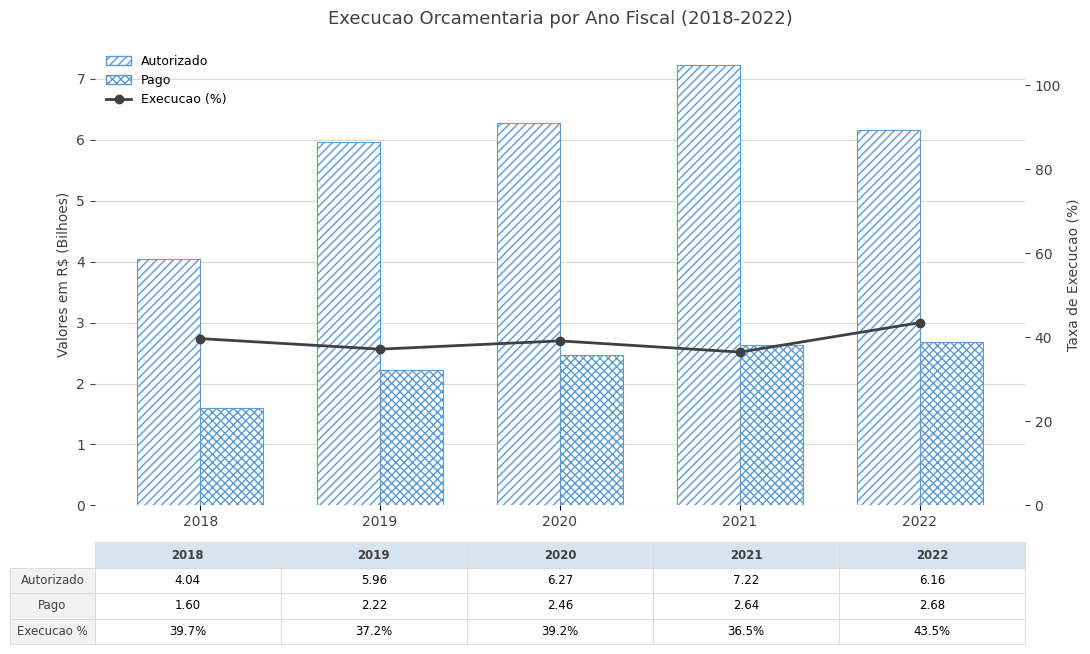

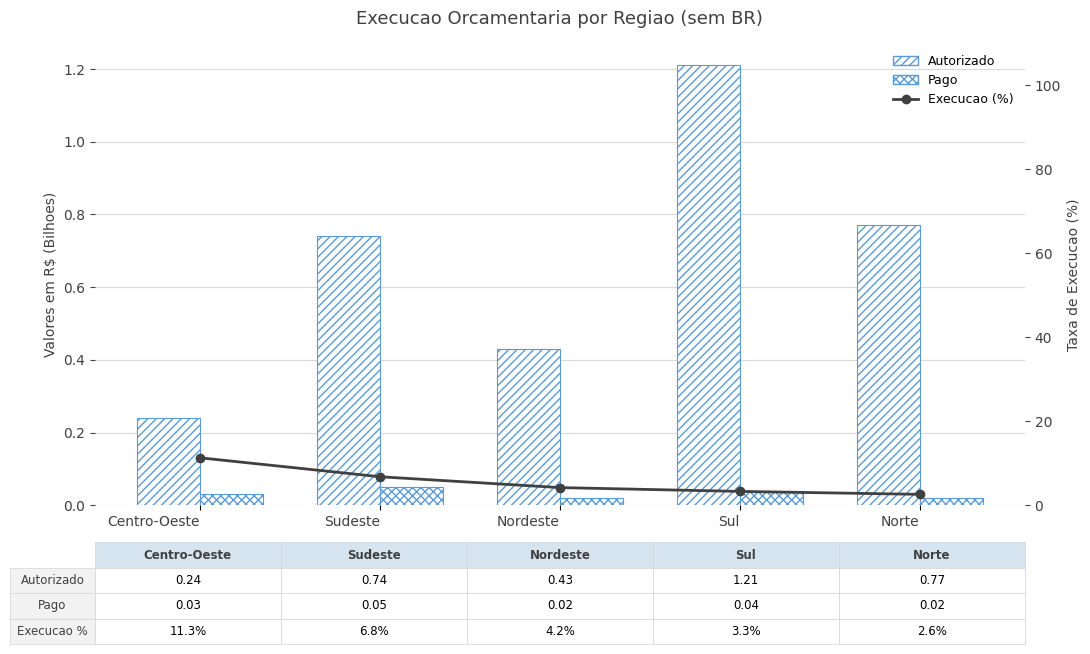

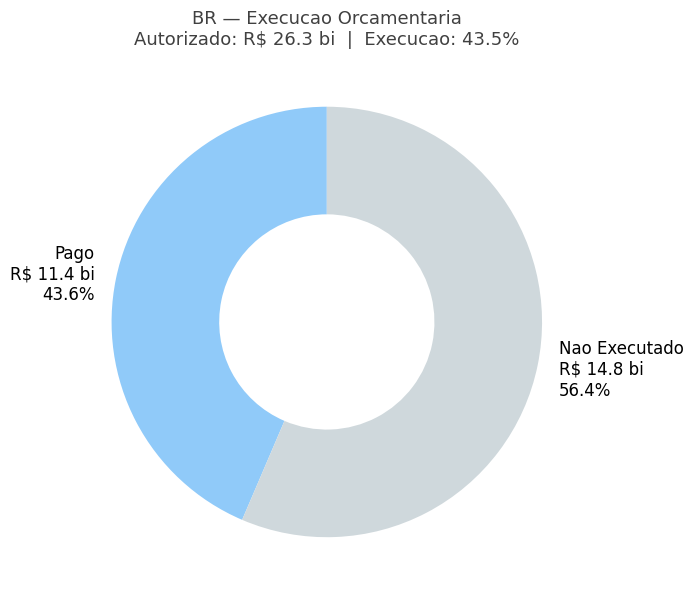

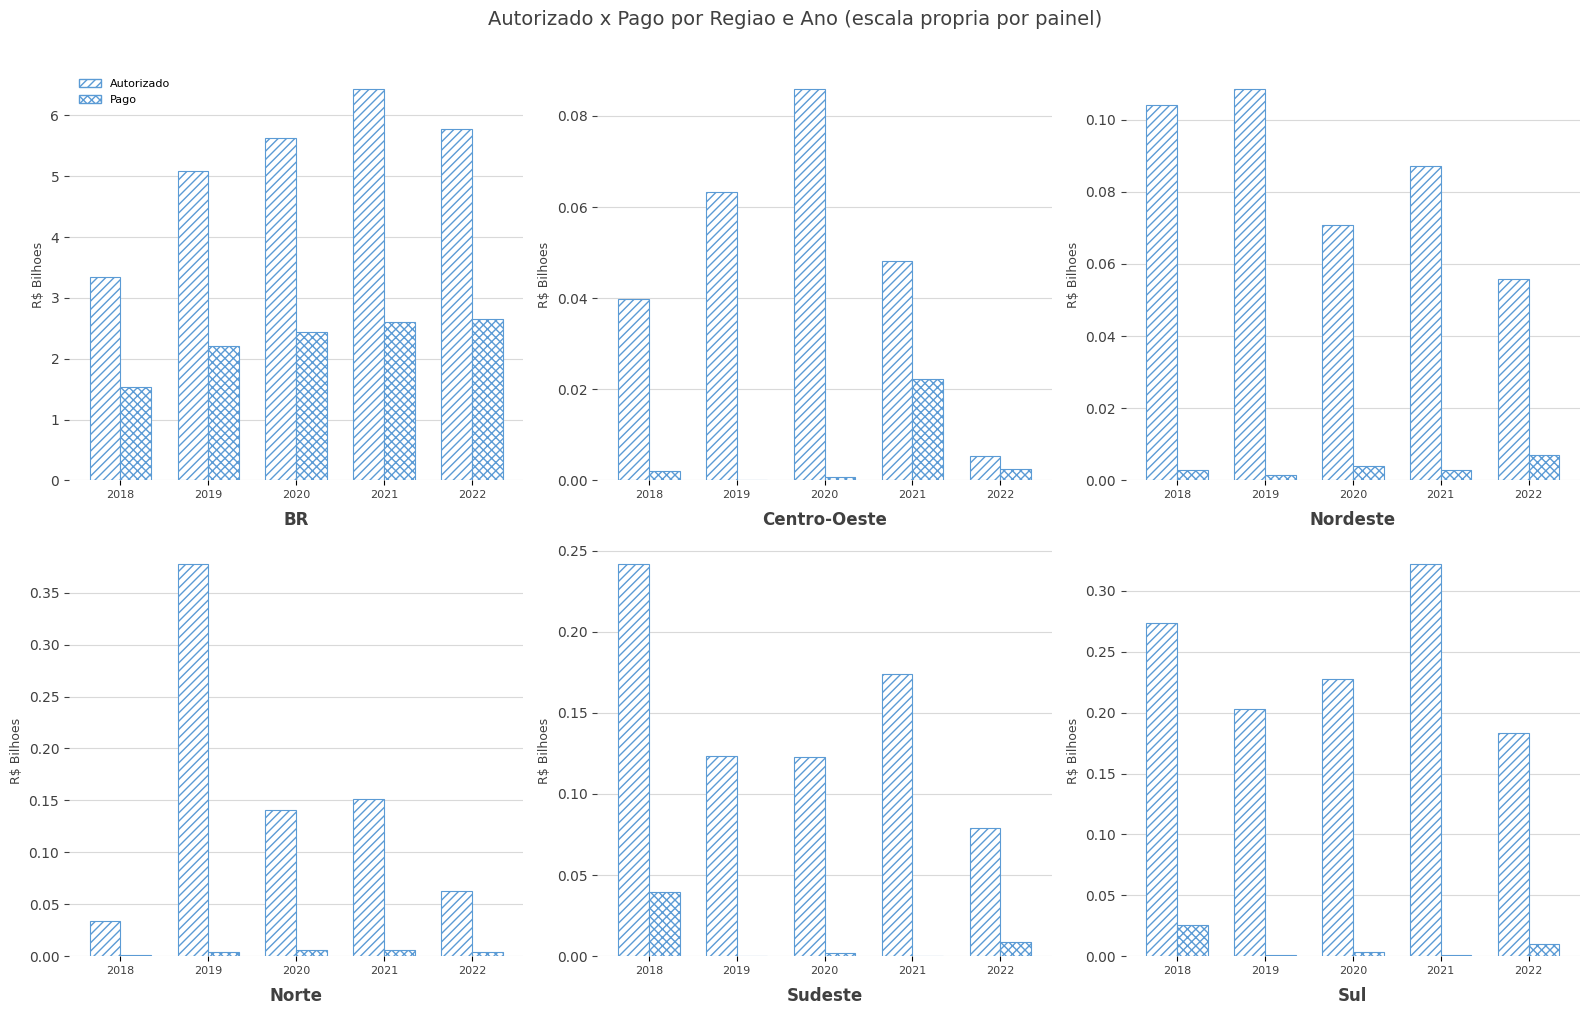

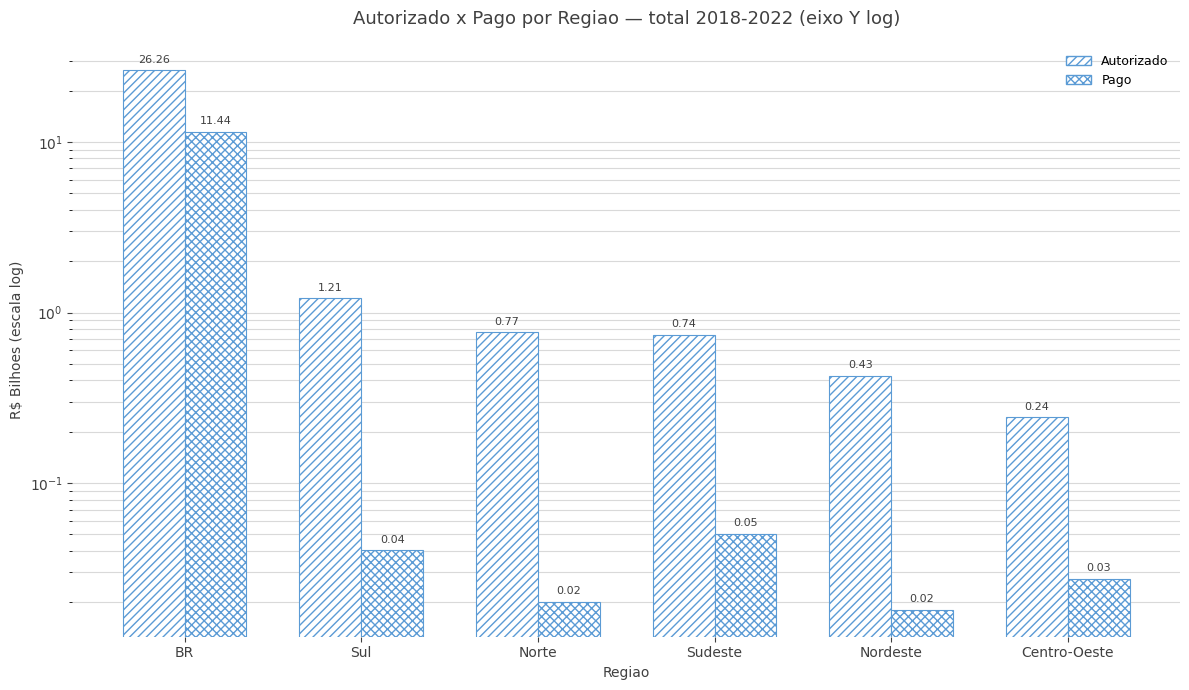


Salvo: output/base_step_10_execucao_ano.csv,base_step_10_regiao.csv, base_step_10_execucao_ano.png, base_step_10_execucao_regiao.png, base_step_10_execucao_br_rosca.png, base_step_10_small_multiples.png, base_step_10_barras_log_2d.png


In [43]:
# -------------------------------------------------------------
# STEP 10 VIZ - Analise de execucao orcamentaria
# Le a base do STEP 04 e calcula a taxa de execucao (Pago/Autorizado)
# por ano fiscal e por regiao. A taxa e sempre soma(Pago)/soma(Autorizado)
# do recorte, nao media de razoes linha a linha (linhas com Autorizado
# zero distorceriam a media). Salva as tabelas e plota a evolucao.
# Inclui Alt 1 (small multiples por regiao) e Alt 3 (barras log).
# -------------------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import numpy as np

df = pd.read_csv('output/base_step_04.csv', sep=';', decimal=',', encoding='utf-8-sig')
for c in ['Autorizado', 'Pago']:
    df[c] = pd.to_numeric(df[c].astype(str).str.replace(',', '.'), errors='coerce')

regiao_cols = [c for c in df.columns if c.startswith('regiao_')]
df['regiao'] = df[regiao_cols].idxmax(axis=1).str.replace('regiao_', '', regex=False)

def taxa(grupo):
    aut = grupo['Autorizado'].sum()
    pago = grupo['Pago'].sum()
    return pd.Series({
        'Autorizado_bi': aut / 1e9,
        'Pago_bi': pago / 1e9,
        'Execucao_%': (pago / aut * 100) if aut > 0 else 0
    })

por_ano = df.groupby('exerciciofiscal').apply(taxa, include_groups=False).round(2)
por_ano.to_csv('output/base_step_10_execucao_ano.csv', sep=';', encoding='utf-8-sig')

por_regiao = df.groupby('regiao').apply(taxa, include_groups=False).round(2)
por_regiao = por_regiao.sort_values('Execucao_%', ascending=False)
por_regiao.to_csv('output/base_step_10_execucao_regiao.csv', sep=';', encoding='utf-8-sig')

print("=" * 55)
print("EXECUCAO ORCAMENTARIA POR ANO FISCAL")
print("=" * 55)
print(por_ano.to_string())
print("\n" + "=" * 55)
print("EXECUCAO ORCAMENTARIA POR REGIAO")
print("=" * 55)
print(por_regiao.to_string())

HATCHES     = ['////', 'xxxx']
COR_HACHURA = '#5B9BD5'
GRID_COLOR  = '#D9D9D9'
TITLE_COLOR = '#404040'
TABLE_FS    = 8.5
BW          = 0.35

def estilo_eixo(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(GRID_COLOR)
    ax.spines['bottom'].set_color(GRID_COLOR)
    ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.set_facecolor('white')

def montar_tabela(ax, col_labels, row_data):
    tbl = ax.table(
        cellText=row_data,
        rowLabels=['Autorizado', 'Pago', 'Execucao %'],
        colLabels=col_labels,
        cellLoc='center', rowLoc='center',
        bbox=[0, -0.30, 1, 0.22]
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(TABLE_FS)
    for (r, c), cell in tbl.get_celld().items():
        cell.set_edgecolor(GRID_COLOR)
        cell.set_linewidth(0.6)
        if r == 0:
            cell.set_facecolor('#D6E4F0')
            cell.set_text_props(color=TITLE_COLOR, fontweight='bold')
        elif c == -1:
            cell.set_facecolor('#F2F2F2')
            cell.set_text_props(color=TITLE_COLOR)
        else:
            cell.set_facecolor('white')

leg_patches = [
    mpatches.Patch(facecolor='white', hatch=HATCHES[0],
                   edgecolor=COR_HACHURA, label='Autorizado'),
    mpatches.Patch(facecolor='white', hatch=HATCHES[1],
                   edgecolor=COR_HACHURA, label='Pago'),
]
leg_line = Line2D([0], [0], color='#404040', marker='o', linewidth=2, label='Execucao (%)')

# =============================================================
# GRAFICO 1: taxa de execucao por ANO FISCAL
# =============================================================
anos = por_ano.index.astype(str).tolist()
x = np.arange(len(por_ano))

fig, ax1 = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('white')
estilo_eixo(ax1)

ax1.bar(x - BW/2, por_ano['Autorizado_bi'], BW,
        facecolor='white', hatch=HATCHES[0],
        edgecolor=COR_HACHURA, linewidth=0.8, zorder=3)
ax1.bar(x + BW/2, por_ano['Pago_bi'], BW,
        facecolor='white', hatch=HATCHES[1],
        edgecolor=COR_HACHURA, linewidth=0.8, zorder=3)

ax1.set_xticks(x)
ax1.set_xticklabels(anos, fontsize=10, color=TITLE_COLOR)
ax1.set_ylabel('Valores em R$ (Bilhoes)', fontsize=10, color=TITLE_COLOR)
ax1.tick_params(axis='y', colors=TITLE_COLOR)

ax2 = ax1.twinx()
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_color(GRID_COLOR)
ax2.plot(x, por_ano['Execucao_%'], color=TITLE_COLOR,
         marker='o', linewidth=2, markersize=6, zorder=4)
ax2.set_ylabel('Taxa de Execucao (%)', fontsize=10, color=TITLE_COLOR)
ax2.set_ylim(0, 110)
ax2.tick_params(axis='y', colors=TITLE_COLOR)

ax1.legend(handles=leg_patches + [leg_line], loc='upper left', frameon=False, fontsize=9)
plt.title('Execucao Orcamentaria por Ano Fiscal (2018-2022)',
          fontsize=13, color=TITLE_COLOR, fontweight='normal', pad=14)

plt.subplots_adjust(bottom=0.22)
montar_tabela(ax1, anos, [
    [f"{v:.2f}" for v in por_ano['Autorizado_bi']],
    [f"{v:.2f}" for v in por_ano['Pago_bi']],
    [f"{v:.1f}%" for v in por_ano['Execucao_%']],
])

plt.savefig('output/base_step_10_execucao_ano.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# =============================================================
# GRAFICO 2: taxa de execucao por REGIAO (sem BR)
# =============================================================
por_regiao_sem_br = por_regiao[por_regiao.index != 'BR']
regioes = por_regiao_sem_br.index.astype(str).tolist()
x2 = np.arange(len(por_regiao_sem_br))

fig, ax1 = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('white')
estilo_eixo(ax1)

ax1.bar(x2 - BW/2, por_regiao_sem_br['Autorizado_bi'], BW,
        facecolor='white', hatch=HATCHES[0],
        edgecolor=COR_HACHURA, linewidth=0.8, zorder=3)
ax1.bar(x2 + BW/2, por_regiao_sem_br['Pago_bi'], BW,
        facecolor='white', hatch=HATCHES[1],
        edgecolor=COR_HACHURA, linewidth=0.8, zorder=3)

ax1.set_xticks(x2)
ax1.set_xticklabels(regioes, rotation=0, ha='right', fontsize=10, color=TITLE_COLOR)
ax1.set_ylabel('Valores em R$ (Bilhoes)', fontsize=10, color=TITLE_COLOR)
ax1.tick_params(axis='y', colors=TITLE_COLOR)

ax2 = ax1.twinx()
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_color(GRID_COLOR)
ax2.plot(x2, por_regiao_sem_br['Execucao_%'], color=TITLE_COLOR,
         marker='o', linewidth=2, markersize=6, zorder=4)
ax2.set_ylabel('Taxa de Execucao (%)', fontsize=10, color=TITLE_COLOR)
ax2.set_ylim(0, 110)
ax2.tick_params(axis='y', colors=TITLE_COLOR)

ax1.legend(handles=leg_patches + [leg_line], loc='upper right', frameon=False, fontsize=9)
plt.title('Execucao Orcamentaria por Regiao (sem BR)',
          fontsize=13, color=TITLE_COLOR, fontweight='normal', pad=14)

plt.subplots_adjust(bottom=0.22)
montar_tabela(ax1, regioes, [
    [f"{v:.2f}" for v in por_regiao_sem_br['Autorizado_bi']],
    [f"{v:.2f}" for v in por_regiao_sem_br['Pago_bi']],
    [f"{v:.1f}%" for v in por_regiao_sem_br['Execucao_%']],
])

plt.savefig('output/base_step_10_execucao_regiao.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# =============================================================
# GRAFICO 3: rosca BR — Autorizado vs Pago
# =============================================================
br = por_regiao.loc['BR']
valores = [br['Pago_bi'], br['Autorizado_bi'] - br['Pago_bi']]
rotulos = [
    f"Pago\nR$ {br['Pago_bi']:.1f} bi\n{valores[0]/sum(valores)*100:.1f}%",
    f"Nao Executado\nR$ {(br['Autorizado_bi'] - br['Pago_bi']):.1f} bi\n{valores[1]/sum(valores)*100:.1f}%"
]
cores = ['#90CAF9', '#CFD8DC']

fig, ax = plt.subplots(figsize=(7, 7))
fig.patch.set_facecolor('white')
wedges, texts = ax.pie(
    valores,
    labels=rotulos,
    colors=cores,
    startangle=90,
    wedgeprops=dict(width=0.5),
    textprops=dict(fontsize=12)
)

ax.set_title(
    f"BR — Execucao Orcamentaria\n"
    f"Autorizado: R$ {br['Autorizado_bi']:.1f} bi  |  Execucao: {br['Execucao_%']:.1f}%",
    fontsize=13, fontweight='normal', color=TITLE_COLOR
)
plt.tight_layout()
plt.savefig('output/base_step_10_execucao_br_rosca.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# =============================================================
# GRAFICO 4: Small multiples - um painel de barras por regiao
# =============================================================
aut  = df.pivot_table(index='regiao', columns='exerciciofiscal',
                      values='Autorizado', aggfunc='sum', fill_value=0) / 1e9
pago = df.pivot_table(index='regiao', columns='exerciciofiscal',
                      values='Pago',        aggfunc='sum', fill_value=0) / 1e9

regioes_alt1 = list(aut.index)
anos_alt1    = list(aut.columns)
x_alt1       = np.arange(len(anos_alt1))

ncols = 3
nrows = int(np.ceil(len(regioes_alt1) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
fig.patch.set_facecolor('white')
axes = axes.ravel()

for k, reg in enumerate(regioes_alt1):
    ax = axes[k]
    estilo_eixo(ax)
    ax.bar(x_alt1 - BW/2, aut.loc[reg], BW,
           facecolor='white', hatch=HATCHES[0],
           edgecolor=COR_HACHURA, linewidth=0.8, zorder=3)
    ax.bar(x_alt1 + BW/2, pago.loc[reg], BW,
           facecolor='white', hatch=HATCHES[1],
           edgecolor=COR_HACHURA, linewidth=0.8, zorder=3)
    ax.set_xlabel(reg, fontsize=12, fontweight='bold', color=TITLE_COLOR, labelpad=8)
    ax.set_xticks(x_alt1)
    ax.set_xticklabels([str(a) for a in anos_alt1], fontsize=8, color=TITLE_COLOR)
    ax.set_ylabel('R$ Bilhoes', fontsize=9, color=TITLE_COLOR)
    ax.tick_params(axis='y', colors=TITLE_COLOR)
    if k == 0:
        ax.legend(handles=leg_patches, frameon=False, fontsize=8,
                  loc='upper left')

for k in range(len(regioes_alt1), len(axes)):
    axes[k].axis('off')

plt.suptitle('Autorizado x Pago por Regiao e Ano (escala propria por painel)',
             fontsize=14, color=TITLE_COLOR, fontweight='normal', y=1.01)
plt.tight_layout()
plt.savefig('output/base_step_10_small_multiples.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
plt.close()

# =============================================================
# GRAFICO 5: Barras agrupadas 2D com eixo Y logaritmico
# =============================================================
resumo  = df.groupby('regiao')[['Autorizado', 'Pago']].sum() / 1e9
resumo  = resumo.sort_values('Autorizado', ascending=False)
regioes_alt3 = list(resumo.index)
x_alt3       = np.arange(len(regioes_alt3))

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('white')
estilo_eixo(ax)
ax.yaxis.grid(False)
ax.set_yscale('log')
ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.8, zorder=0, which='both')

ax.bar(x_alt3 - BW/2, resumo['Autorizado'], BW,
       facecolor='white', hatch=HATCHES[0],
       edgecolor=COR_HACHURA, linewidth=0.8, zorder=3)
ax.bar(x_alt3 + BW/2, resumo['Pago'], BW,
       facecolor='white', hatch=HATCHES[1],
       edgecolor=COR_HACHURA, linewidth=0.8, zorder=3)

ax.set_xticks(x_alt3)
ax.set_xticklabels(regioes_alt3, fontsize=10, color=TITLE_COLOR)
ax.set_xlabel('Regiao', fontsize=10, color=TITLE_COLOR)
ax.set_ylabel('R$ Bilhoes (escala log)', fontsize=10, color=TITLE_COLOR)
ax.tick_params(axis='both', colors=TITLE_COLOR)

for i, reg in enumerate(regioes_alt3):
    val_aut  = resumo['Autorizado'].iloc[i]
    val_pago = resumo['Pago'].iloc[i]
    ax.text(i - BW/2, val_aut  * 1.08, f"{val_aut:.2f}",
            ha='center', va='bottom', fontsize=8, color=TITLE_COLOR)
    ax.text(i + BW/2, val_pago * 1.08, f"{val_pago:.2f}",
            ha='center', va='bottom', fontsize=8, color=TITLE_COLOR)

ax.legend(handles=leg_patches, frameon=False, fontsize=9, loc='upper right')
plt.title('Autorizado x Pago por Regiao — total 2018-2022 (eixo Y log)',
          fontsize=13, color=TITLE_COLOR, fontweight='normal', pad=14)
plt.tight_layout()
plt.savefig('output/base_step_10_barras_log_2d.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
plt.close()

print("\nSalvo: output/base_step_10_execucao_ano.csv,base_step_10_regiao.csv, "
      "base_step_10_execucao_ano.png, base_step_10_execucao_regiao.png, base_step_10_execucao_br_rosca.png, "
      "base_step_10_small_multiples.png, base_step_10_barras_log_2d.png")

In [44]:
# -------------------------------------------------------------
# STEP 11 - Estatistica descritiva ampliada
# Le a base do STEP 04, reconstroi regiao, unidade orcamentaria e
# tipo de acao a partir das dummies e gera tabelas com numero de
# registros, soma autorizada e paga em bilhoes, participacao no total
# e taxa de execucao. Salva uma tabela por recorte em output/.
# -------------------------------------------------------------
import pandas as pd

df = pd.read_csv('output/base_step_04.csv', sep=';', decimal=',', encoding='utf-8-sig')

df['Autorizado'] = pd.to_numeric(df['Autorizado'].astype(str).str.replace(',', '.'), errors='coerce')
df['Pago'] = pd.to_numeric(df['Pago'].astype(str).str.replace(',', '.'), errors='coerce')

# reconstruir as categoricas a partir das dummies do STEP 04
regiao_cols = [c for c in df.columns if c.startswith('regiao_')]
df['regiao'] = df[regiao_cols].idxmax(axis=1).str.replace('regiao_', '', regex=False)

unidade_cols = [c for c in df.columns if c.startswith('unidadeorcamentaria_')]
df['unidadeorcamentaria'] = df[unidade_cols].idxmax(axis=1).str.replace('unidadeorcamentaria_', '', regex=False)

tipoacao_cols = [c for c in df.columns if c.startswith('tipoacao_')]
df['tipoacao'] = df[tipoacao_cols].idxmax(axis=1).str.replace('tipoacao_', '', regex=False)

total_autorizado = df['Autorizado'].sum()

# --- distribuicao por regiao ---
tab_regiao = df.groupby('regiao').agg(Registros=('Autorizado', 'size'),
                                      Autorizado=('Autorizado', 'sum'),
                                      Pago=('Pago', 'sum'))
tab_regiao['Autorizado_bi'] = tab_regiao['Autorizado'] / 1e9
tab_regiao['Pago_bi'] = tab_regiao['Pago'] / 1e9
tab_regiao['Participacao_%'] = tab_regiao['Autorizado'] / total_autorizado * 100
tab_regiao['Execucao_%'] = tab_regiao['Pago'] / tab_regiao['Autorizado'] * 100
tab_regiao = tab_regiao[['Registros', 'Autorizado_bi', 'Pago_bi', 'Participacao_%', 'Execucao_%']].sort_values('Autorizado_bi', ascending=False).round(2)
tab_regiao.to_csv('output/base_step_11_descritiva_regiao.csv', sep=';', encoding='utf-8-sig')

# --- distribuicao por unidade orcamentaria ---
tab_unidade = df.groupby('unidadeorcamentaria').agg(Registros=('Autorizado', 'size'),
                                                    Autorizado=('Autorizado', 'sum'),
                                                    Pago=('Pago', 'sum'))
tab_unidade['Autorizado_bi'] = tab_unidade['Autorizado'] / 1e9
tab_unidade['Pago_bi'] = tab_unidade['Pago'] / 1e9
tab_unidade['Participacao_%'] = tab_unidade['Autorizado'] / total_autorizado * 100
tab_unidade['Execucao_%'] = tab_unidade['Pago'] / tab_unidade['Autorizado'] * 100
tab_unidade = tab_unidade[['Registros', 'Autorizado_bi', 'Pago_bi', 'Participacao_%', 'Execucao_%']].sort_values('Autorizado_bi', ascending=False).round(2)
tab_unidade.to_csv('output/base_step_11_descritiva_unidadeorcamentaria.csv', sep=';', encoding='utf-8-sig')

# --- distribuicao por tipo de acao ---
tab_tipoacao = df.groupby('tipoacao').agg(Registros=('Autorizado', 'size'),
                                          Autorizado=('Autorizado', 'sum'),
                                          Pago=('Pago', 'sum'))
tab_tipoacao['Autorizado_bi'] = tab_tipoacao['Autorizado'] / 1e9
tab_tipoacao['Pago_bi'] = tab_tipoacao['Pago'] / 1e9
tab_tipoacao['Participacao_%'] = tab_tipoacao['Autorizado'] / total_autorizado * 100
tab_tipoacao['Execucao_%'] = tab_tipoacao['Pago'] / tab_tipoacao['Autorizado'] * 100
tab_tipoacao = tab_tipoacao[['Registros', 'Autorizado_bi', 'Pago_bi', 'Participacao_%', 'Execucao_%']].sort_values('Autorizado_bi', ascending=False).round(2)
tab_tipoacao.to_csv('output/base_step_11_descritiva_tipoacao.csv', sep=';', encoding='utf-8-sig')

print("DISTRIBUICAO POR REGIAO")
print(tab_regiao.to_string())
print("\nDISTRIBUICAO POR UNIDADE ORCAMENTARIA")
print(tab_unidade.to_string())
print("\nDISTRIBUICAO POR TIPO DE ACAO")
print(tab_tipoacao.to_string())

print("\nSalvo em output/base_step_11_descritiva_regiao.csv, base_step_11_unidadeorcamentaria.csv e base_step_11_tipoacao.csv")

DISTRIBUICAO POR REGIAO
              Registros  Autorizado_bi  Pago_bi  Participacao_%  Execucao_%
regiao                                                                     
BR                  105          26.26    11.44           88.58       43.54
Sul                  47           1.21     0.04            4.08        3.33
Norte                94           0.77     0.02            2.58        2.63
Sudeste              62           0.74     0.05            2.50        6.82
Nordeste            107           0.43     0.02            1.44        4.24
Centro-Oeste         50           0.24     0.03            0.82       11.33

DISTRIBUICAO POR UNIDADE ORCAMENTARIA
                     Registros  Autorizado_bi  Pago_bi  Participacao_%  Execucao_%
unidadeorcamentaria                                                               
MAPA                       271          19.59     9.14           66.07       46.64
CONAB                       16           6.01     1.00           20.26       16.

In [45]:
# -------------------------------------------------------------
# STEP 12 VIZ - Grafico 3D interativo: IDH x Orientacao Tecnica x PIB_Agro
# Le a base do STEP 04, reconstroi a regiao a partir das dummies e
# plota a dispersao 3D interativa (rotacao nos tres eixos) com pontos
# coloridos por regiao. Salva HTML interativo e renderiza na celula.
# -------------------------------------------------------------
import pandas as pd
import plotly.graph_objects as go

df = pd.read_csv('output/base_step_04.csv', sep=';', decimal=',', encoding='utf-8-sig')

for c in ['IDH', '%_Receber_Orientacao_Tecnica', '%_PIB_Agronegocio']:
    df[c] = pd.to_numeric(df[c].astype(str).str.replace(',', '.'), errors='coerce')

regiao_cols = [c for c in df.columns if c.startswith('regiao_')]
df['regiao'] = df[regiao_cols].idxmax(axis=1).str.replace('regiao_', '', regex=False)

_palette = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860']
categorias = sorted(df['regiao'].unique())
cores_hex = {cat: _palette[i % len(_palette)] for i, cat in enumerate(categorias)}

fig = go.Figure()
for cat in categorias:
    m = (df['regiao'] == cat).values
    fig.add_trace(go.Scatter3d(
        x=df['IDH'][m], y=df['%_Receber_Orientacao_Tecnica'][m], z=df['%_PIB_Agronegocio'][m],
        mode='markers', name=cat,
        marker=dict(size=4, color=cores_hex[cat], opacity=0.7)))

fig.update_layout(
    title='Dispersao 3D - IDH x Orientacao Tecnica x PIB Agro',
    template='plotly_white',
    scene=dict(xaxis_title='IDH', yaxis_title='% Receber Orientacao Tecnica',
               zaxis_title='% PIB Agronegocio'),
    legend=dict(title='Regiao'), height=750)

fig.write_html('output/base_step_12_3d_dispersao.html', include_plotlyjs='cdn')
fig.show()
print("Salvo em output/base_step_12_3d_dispersao.html")

Salvo em output/base_step_12_3d_dispersao.html


In [46]:
# -------------------------------------------------------------
# STEP 13 VIZ - Grafico 3D interativo: superficie de resposta PIB_Agro
# Carrega o modelo do STEP 09 e plota como o %_PIB_Agronegocio previsto
# varia em funcao de %_Receber_Orientacao_Tecnica e IDH, com as demais
# features fixadas na media. Salva HTML interativo e renderiza na celula.
# -------------------------------------------------------------
import pandas as pd
import numpy as np
import pickle
import plotly.graph_objects as go

df = pd.read_csv('output/base_step_04.csv', sep=';', decimal=',', encoding='utf-8-sig')

with open('output/modelo_pibagro_step_09.pkl', 'rb') as f:
    modelo = pickle.load(f)

features = [
    'Pago_USD', 'IDH', 'PIB', 'Log_Pop_Por_Propriedade',
    '%_Receber_Orientacao_Tecnica', 'tipoacao_CAPEX', 'regiao_BR',
    'regiao_Centro-Oeste', 'regiao_Nordeste', 'regiao_Norte',
    'regiao_Sudeste', 'regiao_Sul', 'unidadeorcamentaria_CONAB',
    'unidadeorcamentaria_EMBRAPA', 'unidadeorcamentaria_INCRA',
    'unidadeorcamentaria_MAPA'
]
for c in features:
    df[c] = pd.to_numeric(df[c].astype(str).str.replace(',', '.'), errors='coerce')

eixo_x = '%_Receber_Orientacao_Tecnica'
eixo_y = 'IDH'
gx = np.linspace(df[eixo_x].min(), df[eixo_x].max(), 30)
gy = np.linspace(df[eixo_y].min(), df[eixo_y].max(), 30)
GX, GY = np.meshgrid(gx, gy)

medias = df[features].mean()
grade = pd.DataFrame(np.tile(medias.values, (GX.size, 1)), columns=features)
grade[eixo_x] = GX.ravel()
grade[eixo_y] = GY.ravel()
Z = modelo.predict(grade).reshape(GX.shape)

fig = go.Figure(data=[go.Surface(x=GX, y=GY, z=Z, colorscale='Viridis')])
fig.update_layout(
    title='Superficie de Resposta do Modelo PIB_Agro (STEP 09)',
    template='plotly_white',
    scene=dict(xaxis_title='% Receber Orientacao Tecnica', yaxis_title='IDH',
               zaxis_title='% PIB Agronegocio previsto'), height=750)

fig.write_html('output/base_step_13_3d_superficie.html', include_plotlyjs='cdn')
fig.show()
print("Salvo em output/base_step_13_3d_superficie.html")

Salvo em output/base_step_13_3d_superficie.html


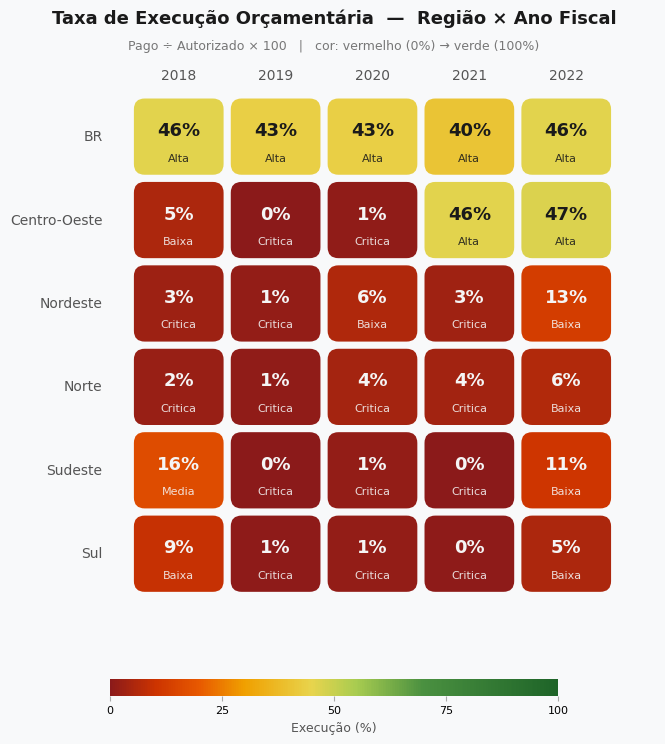

Salvo em output/base_step_14_heatmap_execucao.png


In [47]:
# -------------------------------------------------------------
# STEP 14 VIZ - Heatmap de execucao orcamentaria (regiao x ano)
# Estilo: celulas arredondadas, tag de status, gradiente RdYlGn,
# texto adaptativo (claro/escuro), colorbar horizontal inferior.
# -------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import rcParams

# ── Fonte e estilo base ───────────────────────────────────────
rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.spines.left': False, 'axes.spines.bottom': False})

# ── Dados ─────────────────────────────────────────────────────
df = pd.read_csv('output/base_step_04.csv', sep=';', decimal=',', encoding='utf-8-sig')
df['Autorizado'] = pd.to_numeric(df['Autorizado'].astype(str).str.replace(',', '.'), errors='coerce')
df['Pago']       = pd.to_numeric(df['Pago'].astype(str).str.replace(',', '.'), errors='coerce')

regiao_cols = [c for c in df.columns if c.startswith('regiao_')]
df['regiao']  = df[regiao_cols].idxmax(axis=1).str.replace('regiao_', '', regex=False)

aut   = df.pivot_table(index='regiao', columns='exerciciofiscal', values='Autorizado', aggfunc='sum', fill_value=0)
pago  = df.pivot_table(index='regiao', columns='exerciciofiscal', values='Pago',       aggfunc='sum', fill_value=0)
execucao = (pago / aut.replace(0, np.nan) * 100)

regioes = list(execucao.index)
anos    = list(execucao.columns)
Z       = execucao.values
n_reg, n_ano = len(regioes), len(anos)

# ── Colormap customizado (espelha o gradiente do HTML) ────────
colors_custom = [
    (0.00, '#8B1a1a'),
    (0.10, '#cc3300'),
    (0.20, '#e85a00'),
    (0.30, '#f0a000'),
    (0.45, '#e8d44d'),
    (0.55, '#a8cc50'),
    (0.70, '#4a9040'),
    (1.00, '#1e6428'),
]
from matplotlib.colors import to_rgb
cmap_custom = LinearSegmentedColormap.from_list(
    'execucao',
    [(p, to_rgb(c)) for p, c in colors_custom]
)
norm = plt.Normalize(vmin=0, vmax=100)

# ── Helper: tag de status ─────────────────────────────────────
def status_tag(v):
    if np.isnan(v): return '— N/D'
    if v >= 40: return 'Alta'
    if v >= 15: return 'Media'
    if v >=  5: return 'Baixa'
    return 'Critica'

def status_emoji(v):
    if np.isnan(v): return '○'
    if v >= 40: return '●'   # verde
    if v >= 15: return '●'   # amarelo
    if v >=  5: return '●'   # laranja
    return '●'               # vermelho

# ── Helper: luminância → cor do texto ────────────────────────
def text_color(rgba):
    r, g, b = rgba[:3]
    lum = 0.299*r*255 + 0.587*g*255 + 0.114*b*255
    return '#1a1a1a' if lum > 120 else '#f5f5f5'

# ── Figura ────────────────────────────────────────────────────
CELL_W  = 1.0          # unidade de largura por coluna
CELL_H  = 0.85         # unidade de altura por linha
PAD     = 0.08         # gap entre células (em unidades de dados)
RADIUS  = 0.12         # raio do arredondamento (FancyBboxPatch)

fig_w = n_ano  * (CELL_W + PAD) + 1.6   # 1.6 para rótulos das regiões
fig_h = n_reg  * (CELL_H + PAD) + 1.8   # 1.8 para título + colorbar

fig, ax = plt.subplots(figsize=(fig_w, fig_h))
ax.set_xlim(-0.5, n_ano  * (CELL_W + PAD) - PAD + 0.5)
ax.set_ylim(-0.5, n_reg  * (CELL_H + PAD) - PAD + 0.5)
ax.set_aspect('equal')
ax.axis('off')

fig.patch.set_facecolor('#f8f9fa')
ax.set_facecolor('#f8f9fa')

# ── Desenha células ───────────────────────────────────────────
for i, reg in enumerate(regioes):
    row = n_reg - 1 - i          # inverte: primeira região no topo
    y0  = row * (CELL_H + PAD)

    # rótulo da região (à esquerda)
    ax.text(-0.35, y0 + CELL_H/2, reg,
            ha='right', va='center', fontsize=10, fontweight='500',
            color='#555555')

    for j, ano in enumerate(anos):
        x0 = j * (CELL_W + PAD)
        v  = Z[i, j]

        rgba = cmap_custom(norm(v) if not np.isnan(v) else 0.5)
        fg   = text_color(rgba)

        # célula arredondada
        fancy = mpatches.FancyBboxPatch(
            (x0, y0), CELL_W, CELL_H,
            boxstyle=f"round,pad=0,rounding_size={RADIUS}",
            linewidth=0,
            facecolor=rgba,
            zorder=2
        )
        ax.add_patch(fancy)

        # percentual (grande, centro-topo)
        txt_pct = f'{v:.0f}%' if not np.isnan(v) else 'N/D'
        ax.text(x0 + CELL_W/2, y0 + CELL_H*0.58, txt_pct,
                ha='center', va='center', fontsize=13, fontweight='600',
                color=fg, zorder=3)

        # tag de status (menor, centro-baixo)
        ax.text(x0 + CELL_W/2, y0 + CELL_H*0.22, status_tag(v),
                ha='center', va='center', fontsize=8, fontweight='400',
                color=fg, alpha=0.88, zorder=3)

# ── Cabeçalho dos anos ────────────────────────────────────────
for j, ano in enumerate(anos):
    x0 = j * (CELL_W + PAD)
    ax.text(x0 + CELL_W/2,
            n_reg * (CELL_H + PAD) - PAD + 0.18,
            str(ano),
            ha='center', va='bottom', fontsize=10, fontweight='500',
            color='#555555')

# ── Título ────────────────────────────────────────────────────
fig.text(0.5, 0.97,
         'Taxa de Execução Orçamentária  —  Região × Ano Fiscal',
         ha='center', va='top', fontsize=13, fontweight='600',
         color='#1a1a1a')
fig.text(0.5, 0.93,
         'Pago ÷ Autorizado × 100   |   cor: vermelho (0%) → verde (100%)',
         ha='center', va='top', fontsize=9, color='#777777')

# ── Colorbar horizontal (embaixo) ────────────────────────────
cax = fig.add_axes([0.18, 0.04, 0.64, 0.022])
sm  = plt.cm.ScalarMappable(cmap=cmap_custom, norm=norm)
sm.set_array([])
cb  = fig.colorbar(sm, cax=cax, orientation='horizontal')
cb.set_label('Execução (%)', fontsize=9, color='#555555', labelpad=4)
cb.set_ticks([0, 25, 50, 75, 100])
cb.ax.tick_params(labelsize=8, color='#aaaaaa')
for spine in cb.ax.spines.values():
    spine.set_visible(False)

plt.subplots_adjust(left=0.14, right=0.97, top=0.91, bottom=0.12)
plt.savefig('output/base_step_14_heatmap_execucao.png',
            dpi=150, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()
print("Salvo em output/base_step_14_heatmap_execucao.png")